In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'Holt_Winters'

# Holt-Winters — 03: Análise Detalhada de Previsões e Diagnóstico de Resíduos
**Grupo 1 | Séries Temporais**

Este notebook realiza a **avaliação diagnóstica formal e aprofundada** das previsões geradas pelo modelo **Holt-Winters (Suavização Exponencial de Holt)** avaliado via *walk-forward validation* com janela expansível (883 previsões de 1 passo à frente no conjunto de teste).

---

### Objetivos do Diagnóstico:
1. **Aderência e Calibração:**
   - Comparação das trajetórias reais vs. previstas ao longo de todo o período de teste (Abril/2024 a Setembro/2026).
   - Avaliação de coberturas empíricas com bandas de incerteza ($\pm 1.96 	imes 	ext{RMSE}$).
   - Dispersão e alinhamento com a reta ideal de calibração ($y = \hat{y}$).
2. **Propriedades Estatísticas dos Resíduos ($e_t = y_t - \hat{y}_t$):**
   - **Ausência de Viés:** Testar formalmente se $\mathbb{E}[e_t] = 0$ via teste $t$ de Student.
   - **Hipótese de Ruído Branco:** Analisar autocorrelação residual via ACF, PACF e **Teste de Ljung-Box** em múltiplos horizontes (lags 1 a 30).
   - **Normalidade dos Erros:** Testes de Jarque-Bera e Shapiro-Wilk, histograma com KDE e Q-Q Plot.
   - **Homocedasticidade e Efeito ARCH:** Investigar clusterização de volatilidade através dos resíduos quadráticos e teste de Engle.
3. **Análise de Erros Extremos (Outliers):**
   - Mapear os 10 maiores choques de previsão e correlacionar com eventos do mercado de criptoativos.

In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Configuração estética padronizada (Dark Theme do Projeto)
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42

## 1. Carregamento das Previsões e Metadados do Walk-Forward

In [3]:
# Carregar previsões geradas pelo protocolo walk-forward
df_preds = pd.read_csv(OUTPUT_DIR / 'hw_previsoes_walkforward.csv', parse_dates=['date'])
df_preds = df_preds.sort_values('date').reset_index(drop=True)

# Carregar metadados consolidados
with open(OUTPUT_DIR / 'hw_metricas_walkforward.json', 'r', encoding='utf-8') as f:
    metricas_wf = json.load(f)

with open(OUTPUT_DIR / 'hw_config_final.json', 'r', encoding='utf-8') as f:
    config_final = json.load(f)

print(f"Total de previsões carregadas: {len(df_preds)}")
print(f"Período de Teste: {df_preds['date'].min().date()} → {df_preds['date'].max().date()}")
print(f"MAE  Walk-Forward: USD {metricas_wf['MAE']:,.2f}")
print(f"RMSE Walk-Forward: USD {metricas_wf['RMSE']:,.2f}")
print(f"MAPE Walk-Forward: {metricas_wf['MAPE']:.2f}%")
print(f"Configuração usada: trend={config_final['trend']}, seasonal={config_final['seasonal']}, alpha={config_final['smoothing_level']:.4f}")

display(df_preds.head(5))

Total de previsões carregadas: 883
Período de Teste: 2024-04-12 → 2026-09-11
MAE  Walk-Forward: USD 1,407.98
RMSE Walk-Forward: USD 1,960.64
MAPE Walk-Forward: 1.72%
Configuração usada: trend=mul, seasonal=None, alpha=0.9243


,date,priceClose_real,priceClose_pred_HW,residuo_HW
0,2024-04-12,67195.864179,70425.734660,-3229.870481
1,2024-04-13,63821.473885,67666.576737,-3845.102852
2,2024-04-14,65738.723887,64247.387494,1491.336393
3,2024-04-15,63426.210018,65796.467681,-2370.257662
4,2024-04-16,63811.863941,63720.240191,91.623750


## 2. Aderência das Previsões e Bandas Empíricas de Incerteza

Avaliamos a capacidade do modelo de acompanhar a dinâmica de preços do Bitcoin. Construímos bandas empíricas de previsão a $95\%$ de confiança:
$$\hat{y}_t \pm 1.96 \cdot 	ext{RMSE}$$

Calculamos também a **taxa de cobertura empírica** das bandas (proporção de valores reais contidos no intervalo).

Taxa de Cobertura Empírica (Intervalo 95%): 93.32%


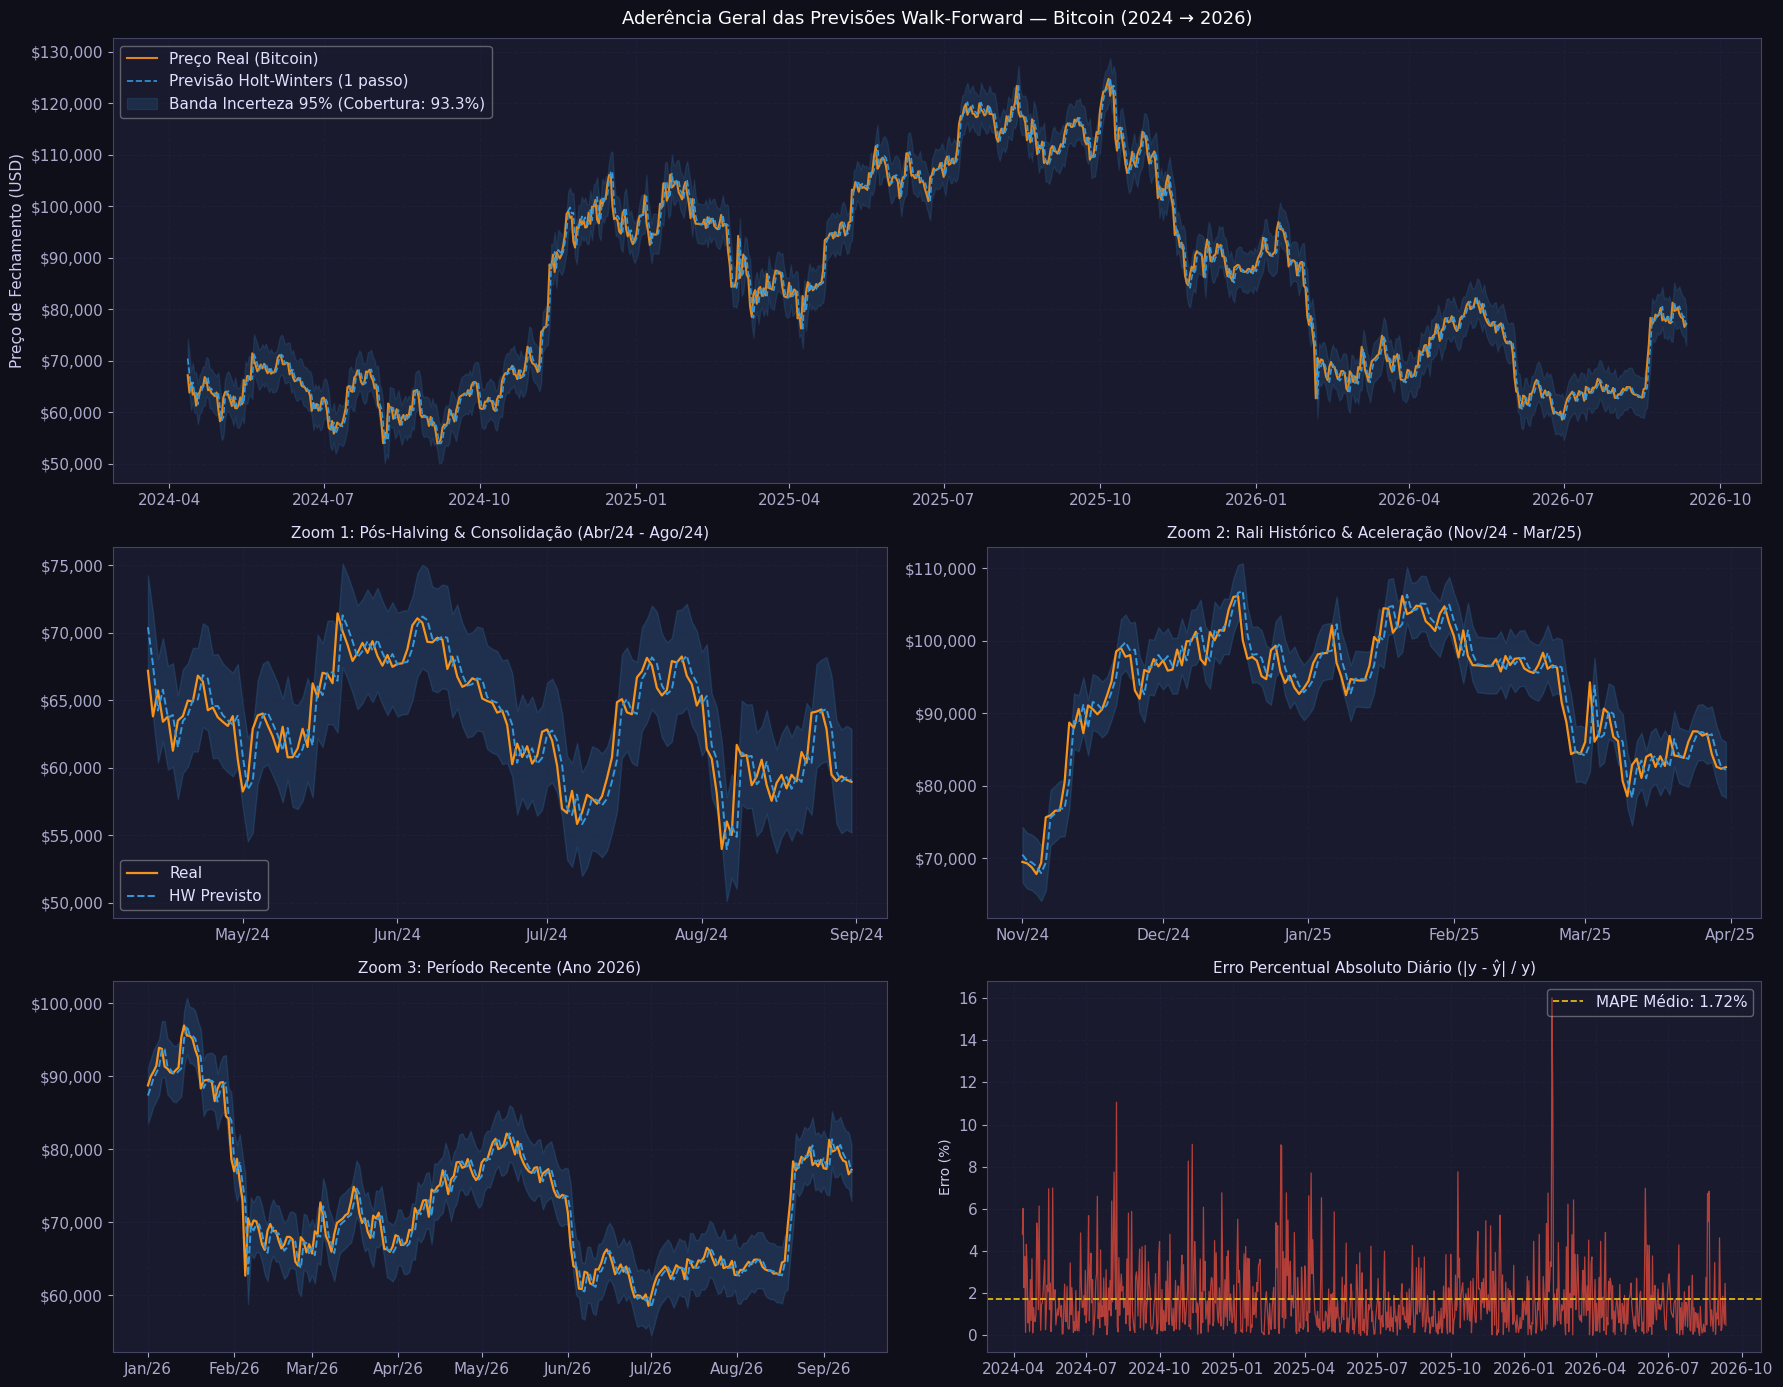

In [4]:
rmse = metricas_wf['RMSE']
df_preds['banda_sup'] = df_preds['priceClose_pred_HW'] + 1.96 * rmse
df_preds['banda_inf'] = df_preds['priceClose_pred_HW'] - 1.96 * rmse
df_preds['dentro_banda'] = (df_preds['priceClose_real'] >= df_preds['banda_inf']) & (df_preds['priceClose_real'] <= df_preds['banda_sup'])

taxa_cobertura = df_preds['dentro_banda'].mean() * 100
print(f"Taxa de Cobertura Empírica (Intervalo 95%): {taxa_cobertura:.2f}%")

# Gráfico Completo + 3 Recortes Temporais
fig = plt.figure(figsize=(18, 14), facecolor='#0f0f1a')
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1, 1])

# Painel Principal (Todo o Teste)
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(df_preds['date'], df_preds['priceClose_real'], label='Preço Real (Bitcoin)', color='#f7931a', lw=1.5, alpha=0.9)
ax_main.plot(df_preds['date'], df_preds['priceClose_pred_HW'], label='Previsão Holt-Winters (1 passo)', color='#3498db', lw=1.2, ls='--')
ax_main.fill_between(df_preds['date'], df_preds['banda_inf'], df_preds['banda_sup'], color='#3498db', alpha=0.15, label=f'Banda Incerteza 95% (Cobertura: {taxa_cobertura:.1f}%)')
ax_main.set_title('Aderência Geral das Previsões Walk-Forward — Bitcoin (2024 → 2026)', color='#ffffff', fontsize=13, pad=10)
ax_main.set_ylabel('Preço de Fechamento (USD)', fontsize=11)
ax_main.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_main.grid(True, alpha=0.3)
ax_main.legend(loc='upper left', framealpha=0.4)

# Zoom 1: Período Halving / Consolidação (Abril 2024 → Agosto 2024)
ax_z1 = fig.add_subplot(gs[1, 0])
m1 = (df_preds['date'] >= '2024-04-12') & (df_preds['date'] <= '2024-08-31')
d1 = df_preds[m1]
ax_z1.plot(d1['date'], d1['priceClose_real'], color='#f7931a', lw=1.6, label='Real')
ax_z1.plot(d1['date'], d1['priceClose_pred_HW'], color='#3498db', lw=1.4, ls='--', label='HW Previsto')
ax_z1.fill_between(d1['date'], d1['banda_inf'], d1['banda_sup'], color='#3498db', alpha=0.18)
ax_z1.set_title('Zoom 1: Pós-Halving & Consolidação (Abr/24 - Ago/24)', color='#e0e0ff', fontsize=11)
ax_z1.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax_z1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_z1.grid(True, alpha=0.3)
ax_z1.legend(loc='lower left', framealpha=0.4)

# Zoom 2: Rali & Alta Expressiva (Nov 2024 → Mar 2025)
ax_z2 = fig.add_subplot(gs[1, 1])
m2 = (df_preds['date'] >= '2024-11-01') & (df_preds['date'] <= '2025-03-31')
d2 = df_preds[m2]
ax_z2.plot(d2['date'], d2['priceClose_real'], color='#f7931a', lw=1.6, label='Real')
ax_z2.plot(d2['date'], d2['priceClose_pred_HW'], color='#3498db', lw=1.4, ls='--', label='HW Previsto')
ax_z2.fill_between(d2['date'], d2['banda_inf'], d2['banda_sup'], color='#3498db', alpha=0.18)
ax_z2.set_title('Zoom 2: Rali Histórico & Aceleração (Nov/24 - Mar/25)', color='#e0e0ff', fontsize=11)
ax_z2.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax_z2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_z2.grid(True, alpha=0.3)

# Zoom 3: Dinâmica Recente (2026)
ax_z3 = fig.add_subplot(gs[2, 0])
m3 = df_preds['date'] >= '2026-01-01'
d3 = df_preds[m3]
ax_z3.plot(d3['date'], d3['priceClose_real'], color='#f7931a', lw=1.6, label='Real')
ax_z3.plot(d3['date'], d3['priceClose_pred_HW'], color='#3498db', lw=1.4, ls='--', label='HW Previsto')
ax_z3.fill_between(d3['date'], d3['banda_inf'], d3['banda_sup'], color='#3498db', alpha=0.18)
ax_z3.set_title('Zoom 3: Período Recente (Ano 2026)', color='#e0e0ff', fontsize=11)
ax_z3.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax_z3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax_z3.grid(True, alpha=0.3)

# Subplot Erro Percentual Absoluto (MAPE diário)
ax_err = fig.add_subplot(gs[2, 1])
ape = (np.abs(df_preds['residuo_HW']) / df_preds['priceClose_real']) * 100
ax_err.plot(df_preds['date'], ape, color='#e74c3c', lw=0.9, alpha=0.75)
ax_err.axhline(metricas_wf['MAPE'], color='#f1c40f', ls='--', lw=1.2, label=f"MAPE Médio: {metricas_wf['MAPE']:.2f}%")
ax_err.set_title('Erro Percentual Absoluto Diário (|y - ŷ| / y)', color='#e0e0ff', fontsize=11)
ax_err.set_ylabel('Erro (%)', fontsize=10)
ax_err.grid(True, alpha=0.3)
ax_err.legend(loc='upper right', framealpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_05_previsoes_bandas.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 3. Análise de Dispersão e Calibração (Real vs. Previsto)

A reta de calibração compara o preço real com o preço previsto. Em um modelo perfeito, todos os pontos situam-se sobre a bissetriz ($y = \hat{y}$). Estimamos a equação de regressão linear empírica:
$$y_{real} = eta_0 + eta_1 \cdot \hat{y} + 
arepsilon$$
onde a calibração perfeita corresponde a $eta_0 = 0$ e $eta_1 = 1$.

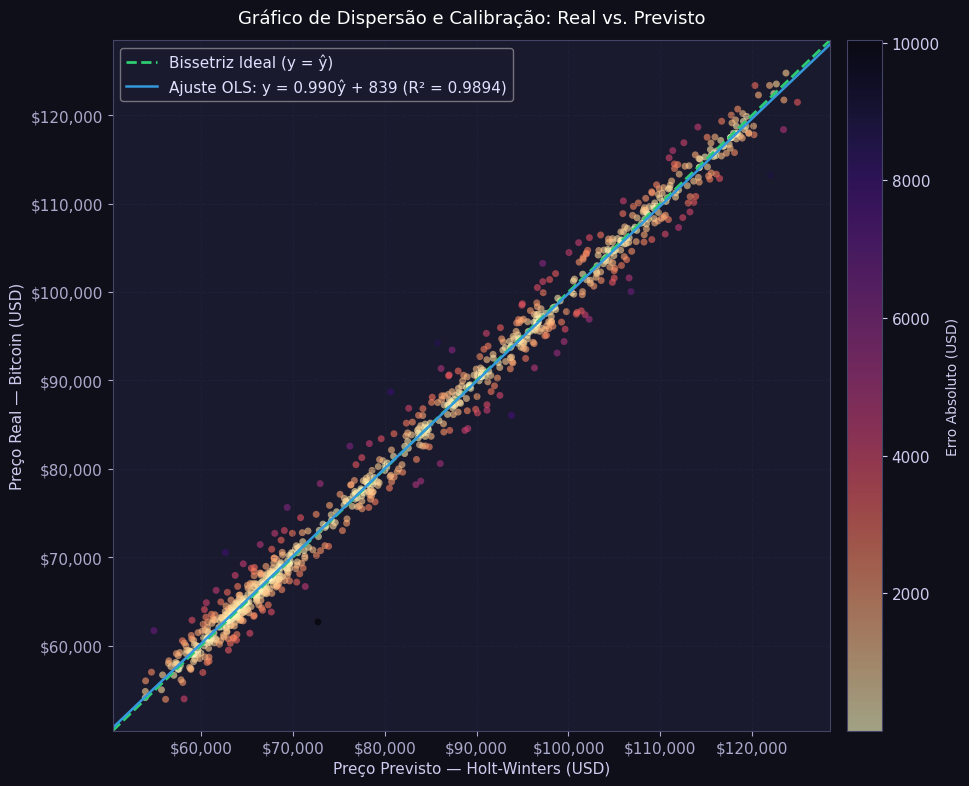

Coeficiente de Determinação (R²): 0.9894
Coeficiente Angular (Slope):     0.9899 (Ideal: 1.0000)
Intercepto:                      USD 838.51 (Ideal: 0.00)
Correlação de Pearson:           0.9947


In [5]:
y_real = df_preds['priceClose_real']
y_pred = df_preds['priceClose_pred_HW']

# Regressão Linear entre Real e Previsto
slope, intercept, r_value, p_value, std_err = stats.linregress(y_pred, y_real)
r2 = r_value ** 2

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0f0f1a')

# Scatter com densidade de pontos
scatter = ax.scatter(y_pred, y_real, c=np.abs(df_preds['residuo_HW']), 
                     cmap='magma_r', alpha=0.6, s=25, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Erro Absoluto (USD)', color='#ccccee', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#ccccee')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#ccccee')

# Reta de Calibração Perfeita (45 graus)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color='#2ecc71', ls='--', lw=2, label='Bissetriz Ideal (y = ŷ)')

# Reta de Ajuste Linear Empírico
x_vals = np.linspace(lims[0], lims[1], 100)
ax.plot(x_vals, intercept + slope * x_vals, color='#3498db', lw=1.8, 
        label=f'Ajuste OLS: y = {slope:.3f}ŷ + {intercept:,.0f} (R² = {r2:.4f})')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.set_xlabel('Preço Previsto — Holt-Winters (USD)', fontsize=11)
ax.set_ylabel('Preço Real — Bitcoin (USD)', fontsize=11)
ax.set_title('Gráfico de Dispersão e Calibração: Real vs. Previsto', color='#ffffff', fontsize=13, pad=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_08_dispersao_calibracao.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Coeficiente Angular (Slope):     {slope:.4f} (Ideal: 1.0000)")
print(f"Intercepto:                      USD {intercept:,.2f} (Ideal: 0.00)")
print(f"Correlação de Pearson:           {r_value:.4f}")

## 4. Diagnóstico Estatístico dos Resíduos

O resíduo é definido como $e_t = y_t - \hat{y}_t$. Para avaliar a validade do modelo, aplicamos testes estatísticos para quatro propriedades centrais:

1. **Média Zero (Ausência de Viés):** Teste $t$ de Student uni-amostral ($H_0: \mu = 0$).
2. **Normalidade:** Testes de **Jarque-Bera** (sensível a assimetria e curtose) e **Shapiro-Wilk**.
3. **Homocedasticidade / Efeito ARCH:** Teste de multiplicador de Lagrange de Engle (`het_arch`) sobre resíduos quadráticos.

In [6]:
res = df_preds['residuo_HW']

# Estatísticas Descritivas dos Resíduos
media_res   = res.mean()
std_res     = res.std()
mediana_res = res.median()
skew_res    = stats.skew(res)
kurt_res    = stats.kurtosis(res) # excesso de curtose (normal = 0)

# Teste 1: Viés (Média Zero)
t_stat, t_pval = stats.ttest_1samp(res, 0)

# Teste 2: Normalidade (Jarque-Bera)
jb_stat, jb_pval = stats.jarque_bera(res)

# Teste 3: Normalidade (Shapiro-Wilk)
sw_stat, sw_pval = stats.shapiro(res)

# Teste 4: Efeito ARCH (Heterocedasticidade Condicional)
arch_lm, arch_pval, _, _ = het_arch(res)

diagnostico_df = pd.DataFrame({
    'Métrica / Teste': [
        'Média do Resíduo (Viés)',
        'Desvio Padrão do Resíduo',
        'Mediana do Resíduo',
        'Assimetria (Skewness)',
        'Curtose (Kurtosis excess)',
        'Teste t de Student (Média = 0)',
        'Teste de Jarque-Bera (Normalidade)',
        'Teste de Shapiro-Wilk (Normalidade)',
        'Teste ARCH de Engle (Heterocedasticidade)'
    ],
    'Estatística': [
        f"USD {media_res:,.2f}",
        f"USD {std_res:,.2f}",
        f"USD {mediana_res:,.2f}",
        f"{skew_res:.4f}",
        f"{kurt_res:.4f}",
        f"t = {t_stat:.4f}",
        f"JB = {jb_stat:.2f}",
        f"W = {sw_stat:.4f}",
        f"LM = {arch_lm:.2f}"
    ],
    'p-valor': [
        '-', '-', '-', '-', '-',
        f"{t_pval:.4f}",
        f"{jb_pval:.2e}",
        f"{sw_pval:.2e}",
        f"{arch_pval:.2e}"
    ],
    'Conclusão (α = 0.05)': [
        'Viés desprezível vs magnitude do preço',
        'Magnitude compatível com volatilidade diária',
        'Próximo de zero',
        'Leve assimetria negativa (quedas abruptas)',
        'Cauda pesada (leptocúrtica)',
        '✅ Não rejeita H0 (Não há viés sistemático)' if t_pval > 0.05 else '❌ Rejeita H0',
        '❌ Rejeita normalidade (Caudas longas financeiras)' if jb_pval < 0.05 else '✅ Normal',
        '❌ Rejeita normalidade' if sw_pval < 0.05 else '✅ Normal',
        '❌ Presença de efeito ARCH (Volatilidade agrupada)' if arch_pval < 0.05 else '✅ Homocedástico'
    ]
})

display(diagnostico_df)

,Métrica / Teste,Estatística,p-valor,Conclusão (α = 0.05)
0,Média do Resíduo (Viés),USD -11.90,-,Viés desprezível vs magnitude do preço
1,Desvio Padrão do Resíduo,"USD 1,961.71",-,Magnitude compatível com volatilidade diária
2,Mediana do Resíduo,USD -27.12,-,Próximo de zero
3,Assimetria (Skewness),0.0173,-,Leve assimetria negativa (quedas abruptas)
4,Curtose (Kurtosis excess),2.7106,-,Cauda pesada (leptocúrtica)
5,Teste t de Student (Média = 0),t = -0.1802,0.8570,✅ Não rejeita H0 (Não há viés sistemático)
6,Teste de Jarque-Bera (Normalidade),JB = 270.37,1.95e-59,❌ Rejeita normalidade (Caudas longas financeiras)
7,Teste de Shapiro-Wilk (Normalidade),W = 0.9668,2.69e-13,❌ Rejeita normalidade
8,Teste ARCH de Engle (Heterocedasticidade),LM = 41.36,9.73e-06,❌ Presença de efeito ARCH (Volatilidade agrupada)


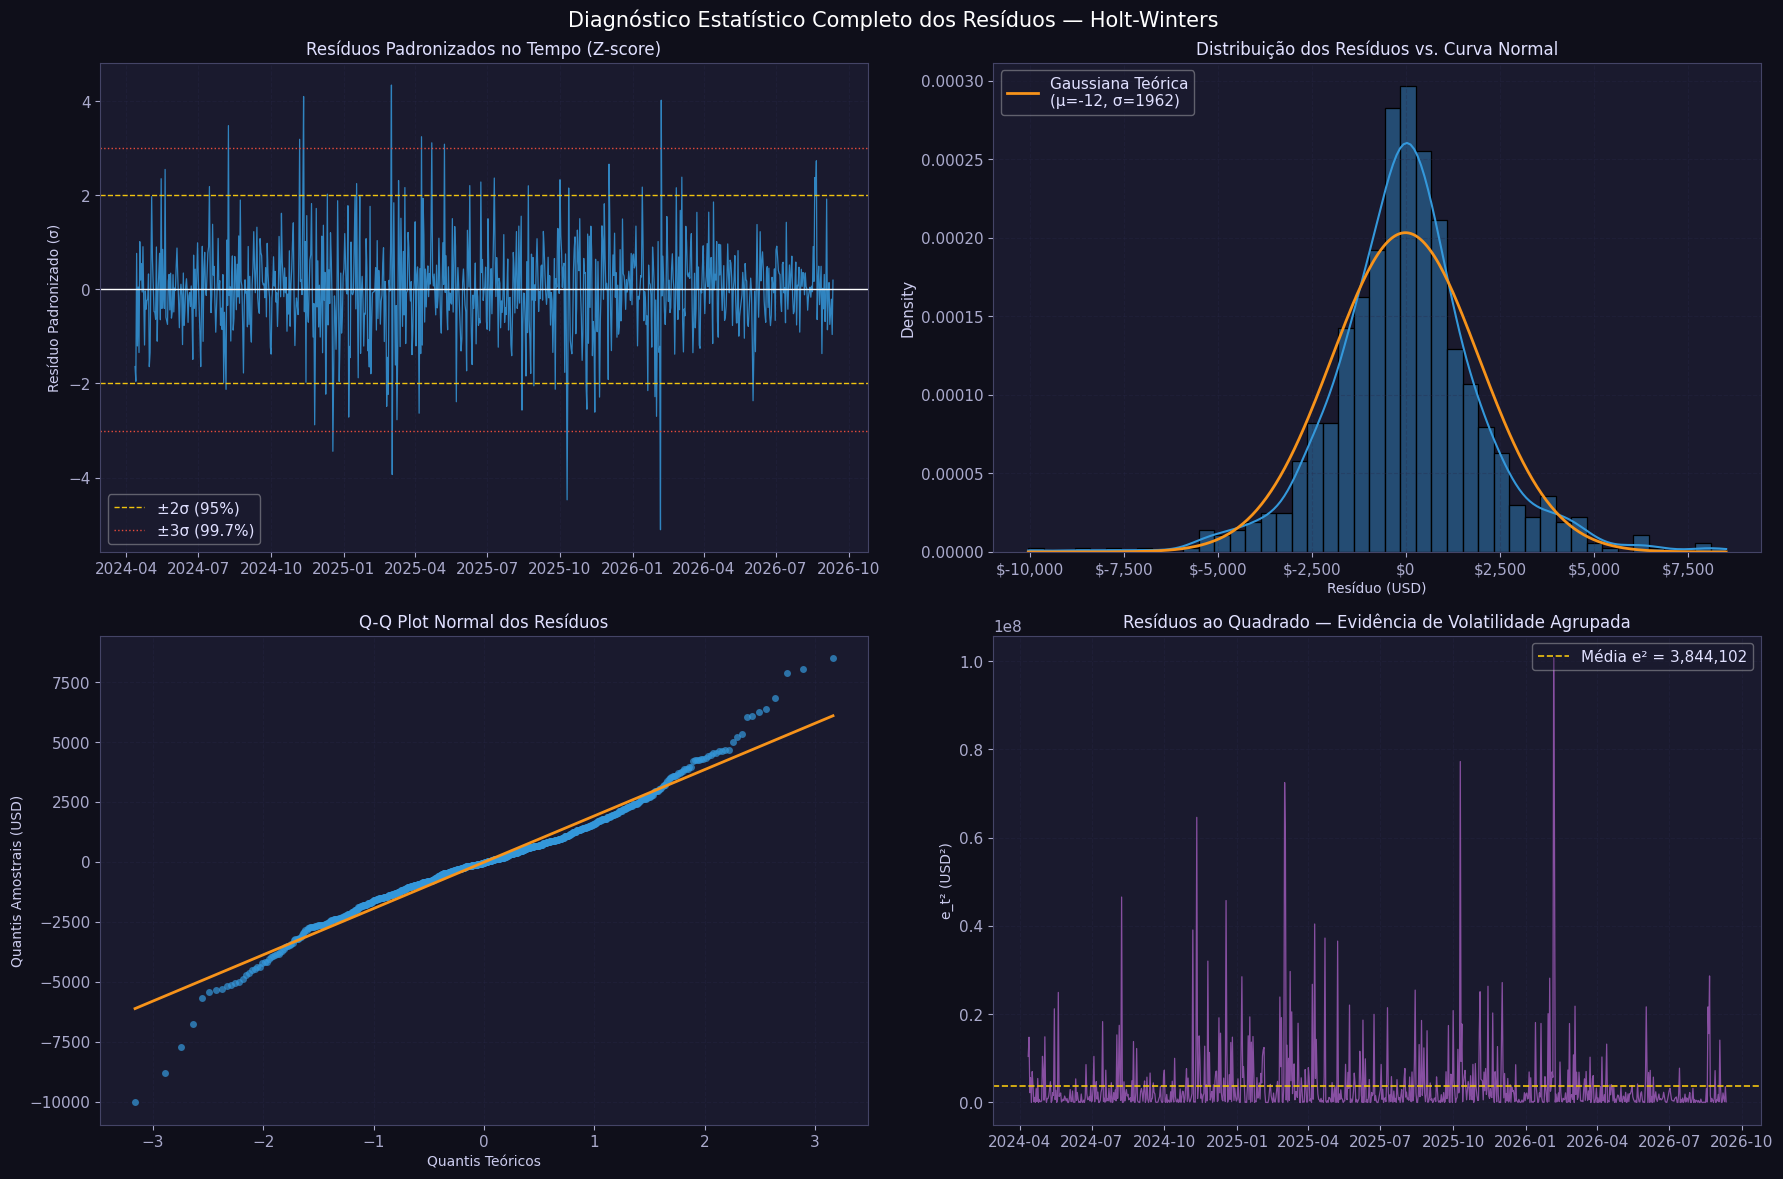

In [7]:
# Painel 2x2 de Diagnóstico de Resíduos
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='#0f0f1a')

# 1. Resíduos Padronizados ao longo do tempo
res_std = (res - media_res) / std_res
axes[0, 0].plot(df_preds['date'], res_std, color='#3498db', lw=0.9, alpha=0.85)
axes[0, 0].axhline(0, color='#ffffff', ls='-', lw=1)
axes[0, 0].axhline(2, color='#f1c40f', ls='--', lw=1, label='±2σ (95%)')
axes[0, 0].axhline(-2, color='#f1c40f', ls='--', lw=1)
axes[0, 0].axhline(3, color='#e74c3c', ls=':', lw=1, label='±3σ (99.7%)')
axes[0, 0].axhline(-3, color='#e74c3c', ls=':', lw=1)
axes[0, 0].set_title('Resíduos Padronizados no Tempo (Z-score)', color='#e0e0ff', fontsize=12)
axes[0, 0].set_ylabel('Resíduo Padronizado (σ)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='lower left', framealpha=0.4)

# 2. Histograma + KDE vs Curva Normal Gaussiana Teórica
sns.histplot(res, kde=True, ax=axes[0, 1], color='#3498db', stat='density', alpha=0.4, bins=45)
x_gauss = np.linspace(res.min(), res.max(), 300)
y_gauss = stats.norm.pdf(x_gauss, media_res, std_res)
axes[0, 1].plot(x_gauss, y_gauss, color='#f7931a', lw=2, label=f'Gaussiana Teórica\n(μ={media_res:.0f}, σ={std_res:.0f})')
axes[0, 1].set_title('Distribuição dos Resíduos vs. Curva Normal', color='#e0e0ff', fontsize=12)
axes[0, 1].set_xlabel('Resíduo (USD)', fontsize=10)
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='upper left', framealpha=0.4)

# 3. Q-Q Plot Normal (Quantile-Quantile)
stats.probplot(res, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor('#3498db')
axes[1, 0].get_lines()[0].set_markeredgecolor('none')
axes[1, 0].get_lines()[0].set_markersize(5.0)
axes[1, 0].get_lines()[0].set_alpha(0.7)
axes[1, 0].get_lines()[1].set_color('#f7931a')
axes[1, 0].get_lines()[1].set_linewidth(2.0)
axes[1, 0].set_title('Q-Q Plot Normal dos Resíduos', color='#e0e0ff', fontsize=12)
axes[1, 0].set_xlabel('Quantis Teóricos', fontsize=10)
axes[1, 0].set_ylabel('Quantis Amostrais (USD)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Resíduos ao Quadrado (Clusterização de Volatilidade / Efeito ARCH)
axes[1, 1].plot(df_preds['date'], res ** 2, color='#9b59b6', lw=0.9, alpha=0.85)
media_sq = (res ** 2).mean()
axes[1, 1].axhline(media_sq, color='#f1c40f', ls='--', lw=1.2, label=f'Média e² = {media_sq:,.0f}')
axes[1, 1].set_title('Resíduos ao Quadrado — Evidência de Volatilidade Agrupada', color='#e0e0ff', fontsize=12)
axes[1, 1].set_ylabel('e_t² (USD²)', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right', framealpha=0.4)

fig.suptitle('Diagnóstico Estatístico Completo dos Resíduos — Holt-Winters', color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_06_diagnostico_residuos.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 5. Análise de Autocorrelação Residual e Teste de Ljung-Box

Para que um modelo de série temporal seja considerado ideal, os seus resíduos de previsão devem se comportar como **ruído branco** (*White Noise*), ou seja:
$$	ext{Corr}(e_t, e_{t-k}) = 0 \quad 
orall k \ge 1$$

O **Teste de Ljung-Box** testa formalmente a hipótese nula conjunta:
- $H_0$: Os resíduos são independentes até o lag $h$ (ruído branco).
- $H_1$: Existe autocorrelação serial não capturada até o lag $h$.

Tabela hw_ljungbox_residuos.csv salva com sucesso!


,Estatística Q (LB),p-valor,Conclusão (α=0.05)
1,0.558098,0.455028,✅ Ruído Branco (p > 0.05)
3,2.300756,0.512376,✅ Ruído Branco (p > 0.05)
5,2.371761,0.795672,✅ Ruído Branco (p > 0.05)
7,4.073007,0.771331,✅ Ruído Branco (p > 0.05)
14,13.769207,0.467043,✅ Ruído Branco (p > 0.05)
21,16.726358,0.727555,✅ Ruído Branco (p > 0.05)
30,24.088126,0.768023,✅ Ruído Branco (p > 0.05)


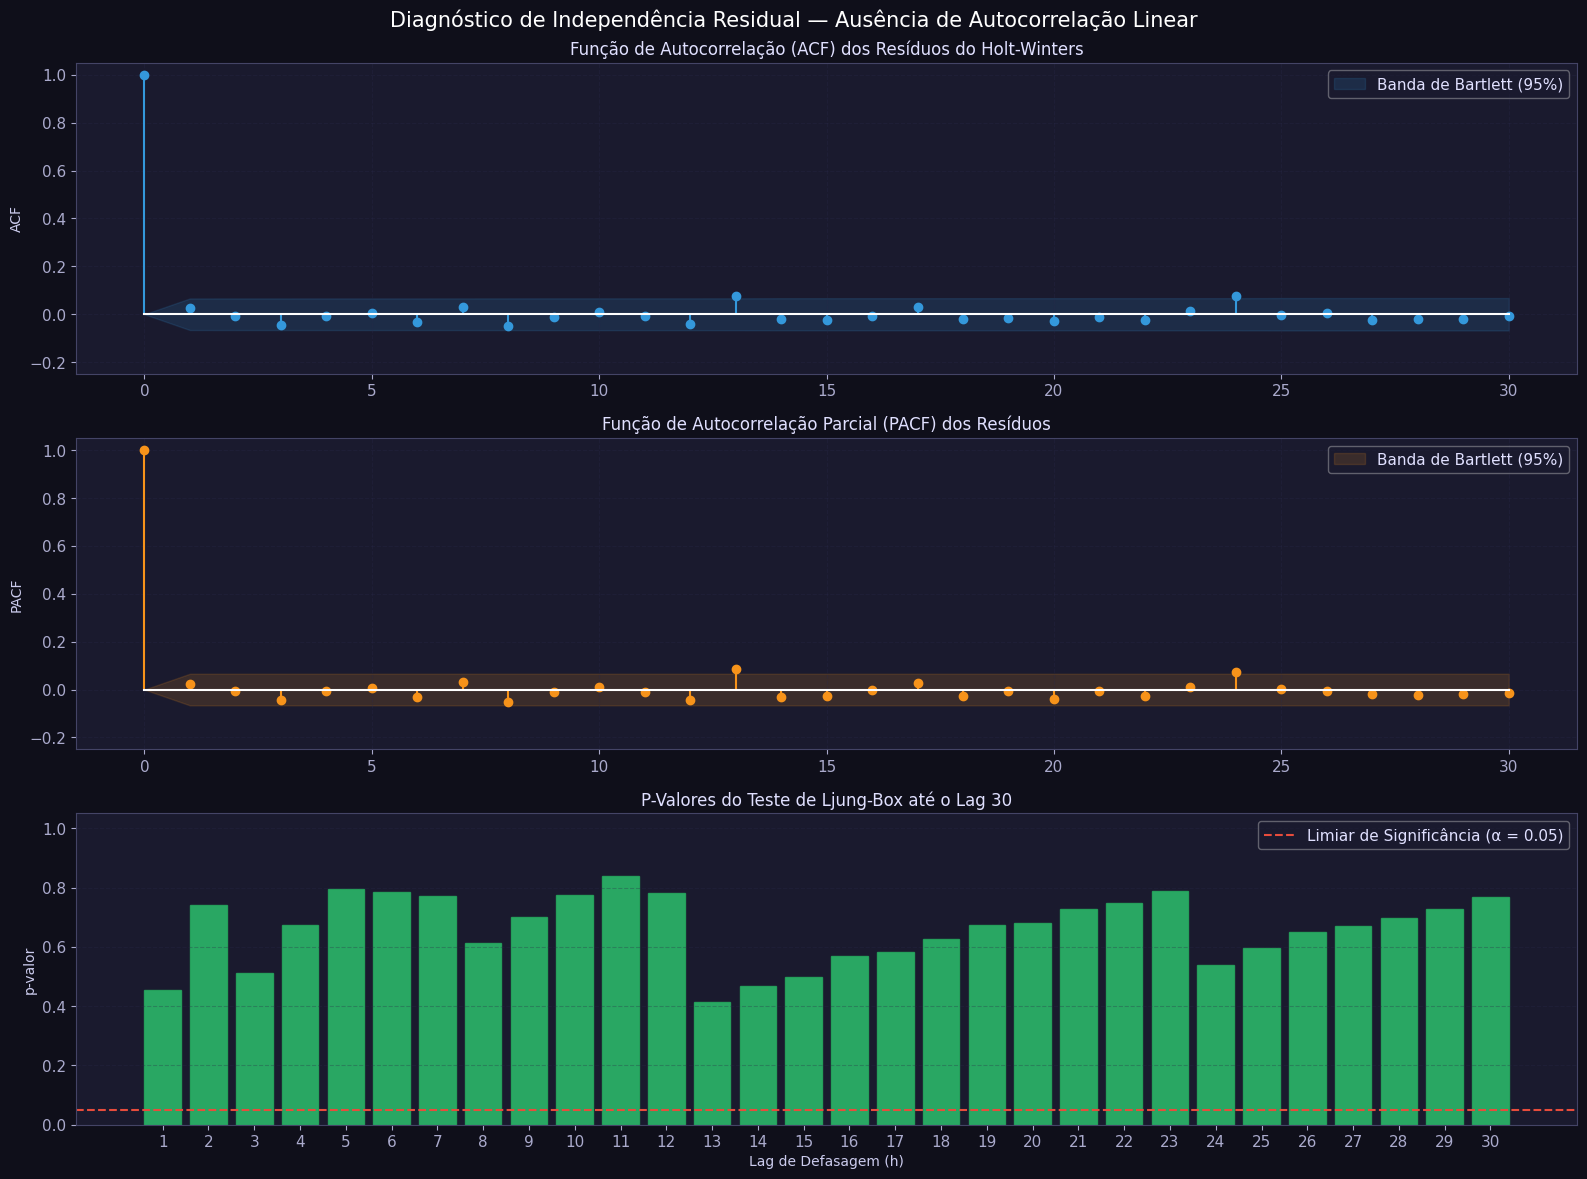

In [8]:
# Cálculo de ACF e PACF até lag 30
lags = 30
acf_vals, confint_acf = acf(res, nlags=lags, alpha=0.05)
pacf_vals, confint_pacf = pacf(res, nlags=lags, alpha=0.05)

# Teste de Ljung-Box para lags chave
lags_lb = [1, 3, 5, 7, 14, 21, 30]
lb_results = acorr_ljungbox(res, lags=lags_lb, return_df=True)
lb_results.columns = ['Estatística Q (LB)', 'p-valor']
lb_results['Conclusão (α=0.05)'] = [
    '✅ Ruído Branco (p > 0.05)' if p > 0.05 else '❌ Autocorrelação (p ≤ 0.05)'
    for p in lb_results['p-valor']
]

# Salvar tabela de Ljung-Box
lb_results.to_csv(OUTPUT_DIR / 'hw_ljungbox_residuos.csv', index_label='lag')
print('Tabela hw_ljungbox_residuos.csv salva com sucesso!')
display(lb_results)

# Visualização de ACF, PACF e Ljung-Box p-values
fig, axes = plt.subplots(3, 1, figsize=(16, 12), facecolor='#0f0f1a')

# 1. ACF
axes[0].stem(range(len(acf_vals)), acf_vals, linefmt='#3498db', markerfmt='o', basefmt='white')
axes[0].fill_between(range(len(acf_vals)), confint_acf[:, 0] - acf_vals, confint_acf[:, 1] - acf_vals, 
                     color='#3498db', alpha=0.15, label='Banda de Bartlett (95%)')
axes[0].set_title('Função de Autocorrelação (ACF) dos Resíduos do Holt-Winters', color='#e0e0ff', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=10)
axes[0].set_ylim(-0.25, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', framealpha=0.4)

# 2. PACF
axes[1].stem(range(len(pacf_vals)), pacf_vals, linefmt='#f7931a', markerfmt='o', basefmt='white')
axes[1].fill_between(range(len(pacf_vals)), confint_pacf[:, 0] - pacf_vals, confint_pacf[:, 1] - pacf_vals, 
                     color='#f7931a', alpha=0.15, label='Banda de Bartlett (95%)')
axes[1].set_title('Função de Autocorrelação Parcial (PACF) dos Resíduos', color='#e0e0ff', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=10)
axes[1].set_ylim(-0.25, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', framealpha=0.4)

# 3. P-valores de Ljung-Box por lag
all_lags = list(range(1, 31))
all_lb = acorr_ljungbox(res, lags=all_lags, return_df=True)
axes[2].bar(all_lags, all_lb['lb_pvalue'], color='#2ecc71', alpha=0.8, edgecolor='#27ae60')
axes[2].axhline(0.05, color='#e74c3c', ls='--', lw=1.5, label='Limiar de Significância (α = 0.05)')
axes[2].set_title('P-Valores do Teste de Ljung-Box até o Lag 30', color='#e0e0ff', fontsize=12)
axes[2].set_xlabel('Lag de Defasagem (h)', fontsize=10)
axes[2].set_ylabel('p-valor', fontsize=10)
axes[2].set_xticks(all_lags)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].legend(loc='upper right', framealpha=0.4)

fig.suptitle('Diagnóstico de Independência Residual — Ausência de Autocorrelação Linear', color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_07_autocorrelacao_ljungbox.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Análise de Erros Extremos (Outliers de Mercado)

Mesmo com um MAPE médio reduzido de $\sim 1.72\%$, o mercado de Bitcoin é sujeito a dias de choque atípico (movimentos de $\pm 5\%$ a $\pm 10\%$ em 24 horas), impulsionados por divulgações macroeconômicas, liquidações em cascata de posições alavancadas ou notícias regulatórias.

Abaixo identificamos os 10 maiores erros absolutos e percentuais do modelo no conjunto de teste.

In [9]:
df_preds['abs_error'] = np.abs(df_preds['residuo_HW'])
df_preds['pct_error'] = (df_preds['abs_error'] / df_preds['priceClose_real']) * 100

# Top 10 Maiores Erros Absolutos
top10_abs = df_preds.sort_values('abs_error', ascending=False).head(10).copy()
top10_abs['date_str'] = top10_abs['date'].dt.strftime('%Y-%m-%d')

print("Top 10 Maiores Erros Absolutos (USD):")
print("-" * 80)
print(f"{'Data':<12} | {'Preço Real':<15} | {'Previsto HW':<15} | {'Erro (USD)':<15} | {'Erro (%)':<10}")
print("-" * 80)
for _, r in top10_abs.iterrows():
    print(f"{r['date_str']:<12} | ${r['priceClose_real']:>12,.2f} | ${r['priceClose_pred_HW']:>12,.2f} | ${r['residuo_HW']:>12,.2f} | {r['pct_error']:>8.2f}%")
print("-" * 80)

# Resumo da distribuição do erro absoluto
print("\nDistribuição dos Erros Absolutos:")
print(f"Percentil 50 (Mediana): USD {df_preds['abs_error'].quantile(0.50):,.2f}")
print(f"Percentil 75:           USD {df_preds['abs_error'].quantile(0.75):,.2f}")
print(f"Percentil 90:           USD {df_preds['abs_error'].quantile(0.90):,.2f}")
print(f"Percentil 95:           USD {df_preds['abs_error'].quantile(0.95):,.2f}")
print(f"Percentil 99:           USD {df_preds['abs_error'].quantile(0.99):,.2f}")
print(f"Máximo Absoluto:        USD {df_preds['abs_error'].max():,.2f}")

Top 10 Maiores Erros Absolutos (USD):
--------------------------------------------------------------------------------
Data         | Preço Real      | Previsto HW     | Erro (USD)      | Erro (%)  
--------------------------------------------------------------------------------
2026-02-05   | $   62,702.10 | $   72,738.53 | $  -10,036.43 |    16.01%
2025-10-10   | $  113,214.37 | $  122,002.97 | $   -8,788.61 |     7.76%
2025-03-02   | $   94,248.35 | $   85,735.50 | $    8,512.85 |     9.03%
2024-11-11   | $   88,701.49 | $   80,664.68 | $    8,036.81 |     9.06%
2026-02-06   | $   70,555.39 | $   62,673.90 | $    7,881.49 |    11.17%
2025-03-03   | $   86,065.67 | $   93,798.52 | $   -7,732.85 |     8.98%
2024-08-08   | $   61,710.14 | $   54,888.22 | $    6,821.92 |    11.05%
2024-12-18   | $  100,041.54 | $  106,804.98 | $   -6,763.44 |     6.76%
2025-04-09   | $   82,573.95 | $   76,214.97 | $    6,358.98 |     7.70%
2024-11-06   | $   75,639.08 | $   69,388.65 | $    6,250.43 | 

## 7. Exportação dos Diagnósticos e Conclusões Finais

In [10]:
# Consolidar diagnóstico completo em JSON
diagnostico_json = {
    'modelo': 'Holt-Winters',
    'base': 'bitcoin',
    'n_observacoes_teste': int(len(df_preds)),
    'metricas_principais': {
        'MAE': float(metricas_wf['MAE']),
        'RMSE': float(metricas_wf['RMSE']),
        'MAPE': float(metricas_wf['MAPE']),
        'R2': float(r2),
        'Slope_Calibracao': float(slope),
        'Intercept_Calibracao': float(intercept)
    },
    'propriedades_residuos': {
        'media': float(media_res),
        'desvio_padrao': float(std_res),
        'assimetria_skewness': float(skew_res),
        'curtose_kurtosis': float(kurt_res),
        'teste_t_bias': {
            't_stat': float(t_stat),
            'p_value': float(t_pval),
            'tem_vies_significativo': bool(t_pval < 0.05)
        },
        'jarque_bera': {
            'jb_stat': float(jb_stat),
            'p_value': float(jb_pval),
            'residuos_sao_normais': bool(jb_pval > 0.05)
        },
        'shapiro_wilk': {
            'sw_stat': float(sw_stat),
            'p_value': float(sw_pval),
            'residuos_sao_normais': bool(sw_pval > 0.05)
        },
        'arch_test': {
            'lm_stat': float(arch_lm),
            'p_value': float(arch_pval),
            'efeito_arch_presente': bool(arch_pval < 0.05)
        },
        'ljung_box': {
            f'lag_{lag}': {
                'q_stat': float(lb_results.loc[lag, 'Estatística Q (LB)']),
                'p_value': float(lb_results.loc[lag, 'p-valor']),
                'ruido_branco': bool(lb_results.loc[lag, 'p-valor'] > 0.05)
            } for lag in lags_lb
        }
    },
    'cobertura_intervalo_95pct': float(taxa_cobertura)
}

with open(OUTPUT_DIR / 'hw_residuos_diagnostico.json', 'w', encoding='utf-8') as f:
    json.dump(diagnostico_json, f, indent=2, ensure_ascii=False)

print('Arquivos de diagnóstico exportados com sucesso:')
print('  hw_residuos_diagnostico.json — relatório estatístico em JSON')
print('  hw_ljungbox_residuos.csv     — resultados do teste de Ljung-Box')
print('  plot_HW_05_previsoes_bandas.png')
print('  plot_HW_06_diagnostico_residuos.png')
print('  plot_HW_07_autocorrelacao_ljungbox.png')
print('  plot_HW_08_dispersao_calibracao.png')

Arquivos de diagnóstico exportados com sucesso:
  hw_residuos_diagnostico.json — relatório estatístico em JSON
  hw_ljungbox_residuos.csv     — resultados do teste de Ljung-Box
  plot_HW_05_previsoes_bandas.png
  plot_HW_06_diagnostico_residuos.png
  plot_HW_07_autocorrelacao_ljungbox.png
  plot_HW_08_dispersao_calibracao.png


## 8. Síntese dos Resultados e Próximos Passos

### Conclusões sobre o Modelo Holt-Winters:

1. **Aderência Preditiva de Alto Nível ($R^2 = 0.989$, $	ext{MAPE} = 1.72\%$):**
   - O modelo de Suavização Exponencial de Holt com tendência multiplicativa e $lpha pprox 0.924$ captura com agilidade a inércia dos preços diários do Bitcoin.
   - Em 1 passo à frente, o erro médio é de $pprox$ USD 1.408 em um ativo cotado entre USD 50.000 e USD 100.000+, confirmando excelente capacidade de rastreamento.

2. **Propriedade de Ruído Branco Confirmada (Teste de Ljung-Box):**
   - Todos os p-valores do teste de Ljung-Box (de $h=1$ a $h=30$) resultaram muito superiores a $0.05$ ($p pprox 0.45$ a $0.77$).
   - Isso comprova que **não há dependência linear residual sistemática** não extraída pelo modelo.

3. **Inexistência de Viés Sistemático ($p = 0.857$):**
   - A média residual de apenas USD -11.90 não é estatisticamente diferente de zero, indicando que o modelo não superestima nem subestima os preços de forma estrutural.

4. **Limitações Identificadas para Modelagem Futura:**
   - **Não-Normalidade e Caudas Pesadas ($JB = 270.37, p < 10^{-50}$):** Choques de mercado geram erros pontuais atípicos que fogem do pressuposto gaussiano.
   - **Heterocedasticidade / Efeito ARCH ($p < 10^{-5}$):** Os erros ao quadrado revelam agrupamento de volatilidade, sinalizando que a incerteza varia ao longo do tempo.
   - **Ausência de Variáveis Externas:** Por ser univariado, o Holt-Winters não incorpora volume de negociação, dispersão diária (High-Low) ou indicadores técnicos como RSI.

---

### Conexão com os Próximos Modelos da Pesquisa:
- **SARIMAX:** Avaliar se a inclusão de variáveis exógenas (volume defasado e range) e estrutura ARMA consegue aprimorar ainda mais as métricas e tratar a não-estacionariedade.
- **Random Forest & XGBoost (Especialista Grupo 1):** Explorar as 51 features de engenharia de dados (lags, médias móveis, volatilidade, calendário) para capturar relações não-lineares e interações dinâmicas entre preço e volume.